# MWE: the dirty image, and where to start a fit

The *dirty image* is the oldest picture in interferometry: synthesise an image directly from the measured visibilities, with no fitting and no regulariser. It is the true image convolved with the dirty beam, plus noise, so it has the right structure at the resolution of the data but with sidelobes, some of them negative. `virgil.imaging.dirty_image` makes one from any data with complex visibilities: for AMIGO DISCO data, from the least-squares estimate of the visibilities on the uv grid given the modes. Data with only V² and closure phases have no phases to synthesise with, so they have no dirty image.

`virgil.imaging.starting_image` sets up an image fit from the data: it fits a star plus a Gaussian envelope, sizes the field and pixels from that, and starts the pixels either from the fitted Gaussian (`start="moments"`) or from the positive part of the dirty image (`start="dirty"`). This notebook compares the two on dense AMI-like data. You should come away knowing what a dirty image shows and when it is worth starting from.

In [1]:
import sys
import time
from pathlib import Path

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()
)
sys.path.insert(0, str(root / "src"))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from virgil.coverage import ami_grid_record
from virgil.fitting import fit
from virgil.imaging import (
    MaxEntropy,
    beam,
    dirty_image,
    image_priors,
    starting_image,
)
from virgil.models import Image, PointSource, System
from virgil.oidata import OIData
from virgil.plotting import plot_model, plot_residual_map
from virgil.scenes import spiral

template = OIData(ami_grid_record(wavelength_m=4.8e-6, rotation_deg=-6.9))
npix, scale = 62, 20.0
fov = npix * scale
truth_image = spiral(
    npix, scale, step_mas=250.0, width_mas=40.0, turns=1.5, fade_mas=500.0
)
truth = System(
    star=PointSource(),
    env=Image.from_brightness(truth_image, scale, flux=0.03),
)
data = template.with_model(truth, key=jax.random.PRNGKey(0))
resolution = beam(data)
print(
    f"{data.vis.size} modes; beam {resolution.major_mas:.0f} x {resolution.minor_mas:.0f} mas; spiral windings 250 mas apart"
)

W1001 13:05:55.767362 10476303 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


588 modes; beam 154 x 131 mas; spiral windings 250 mas apart


## The dirty image

The star dominates the visibilities, so the dirty image is computed with the star removed, using the extended flux of 3% (in practice that comes from the quick parametric fit inside `starting_image`). The DISCO modes are blind to the total flux, so `dirty_image` normalises the estimated visibilities to one at the shortest baselines. The result is dominated by the bright inner part of the spiral, blurred to the size of the beam; the outer arm is only faintly visible among the sidelobes. The residual against the truth (with the dirty image scaled to the truth's peak) shows the missing arm in blue.

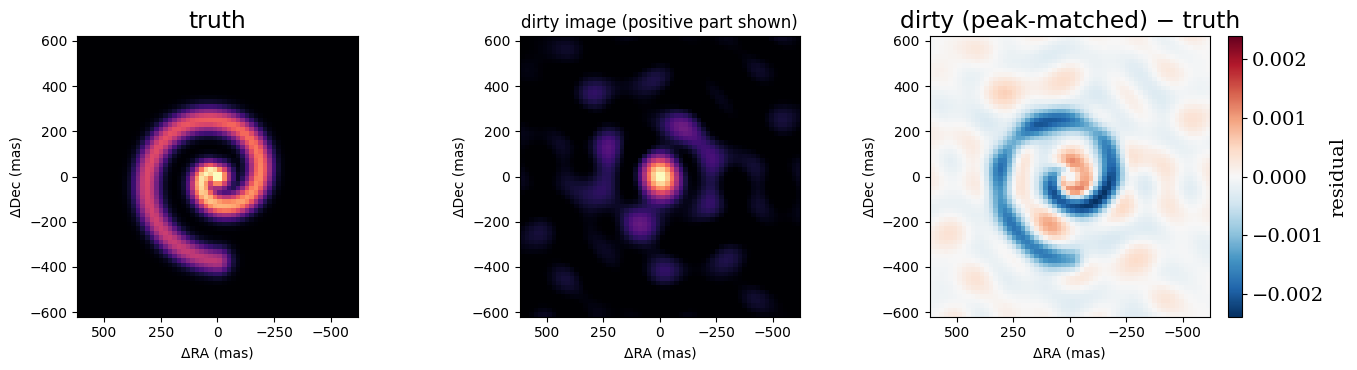

In [2]:
dirty = dirty_image(data, npix, scale, flux_ratio=0.03)
dirty_scaled = dirty * truth_image.max() / dirty.max()
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
plot_model(truth.env, fov_mas=fov, npix=npix, ax=axes[0], title="truth")
axes[1].imshow(
    dirty,
    extent=[fov / 2, -fov / 2, -fov / 2, fov / 2],
    origin="upper",
    cmap="magma",
    vmin=0,
)
axes[1].set(
    title="dirty image (positive part shown)",
    xlabel="ΔRA (mas)",
    ylabel="ΔDec (mas)",
)
plot_residual_map(
    dirty_scaled - truth_image,
    fov_mas=fov,
    ax=axes[2],
    title="dirty (peak-matched) − truth",
)
plt.tight_layout()
plt.show()

## Two starting points

`starting_image` returns a `System` of the star and an `Image` with the fitted flux, in a field and with pixels chosen from the data. Here it is called both ways. The moments start is a smooth Gaussian; the dirty start already has the spiral's shape. Both choose the same field and pixels, about a quarter of the Nyquist scale.

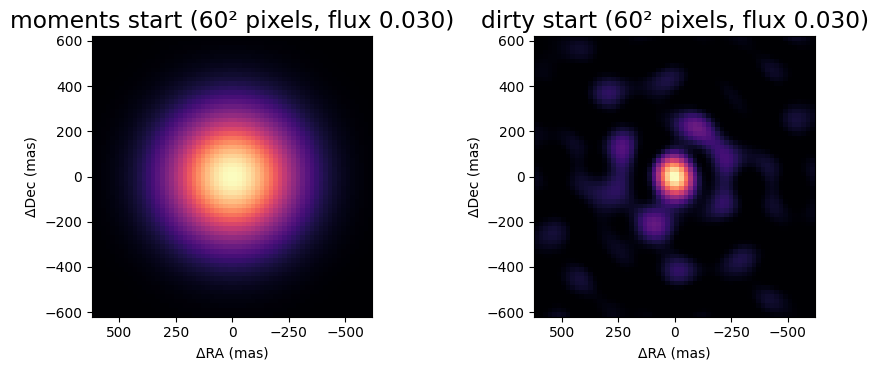

In [3]:
starts = {
    name: starting_image(data, start=name, largest_mas=fov)
    for name in ("moments", "dirty")
}
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, (name, start) in zip(axes, starts.items()):
    shape = start.env.log_brightness.shape
    plot_model(
        start.env,
        fov_mas=fov,
        npix=npix,
        ax=ax,
        title=f"{name} start ({shape[0]}² pixels, flux {float(start.env.flux):.3f})",
    )
plt.tight_layout()
plt.show()

## Fitting from each start

The same maximum-entropy fit is run from both starts. If the problem has one well-defined solution they should end at the same image; the dirty start should get there in fewer steps, because it begins with some of the right structure.

In [4]:
def ncc(a, b):
    a, b = a - a.mean(), b - b.mean()
    return float(jnp.sum(a * b) / jnp.sqrt(jnp.sum(a * a) * jnp.sum(b * b)))


results = {}
for name, start in starts.items():
    begin = time.perf_counter()
    results[name] = fit(
        start, image_priors(start), data, [MaxEntropy(130.0, path="env")]
    )
    seconds = time.perf_counter() - begin
    image = results[name].model.env.render(npix, fov)
    info = results[name].info
    print(
        f"{name:>8} start: {info['steps']:5d} steps in {seconds:4.1f} s, chi2/N {info['chi2_red']:.3f}, NCC with truth {ncc(image, truth_image):.3f}"
    )

 moments start:   721 steps in  2.2 s, chi2/N 0.947, NCC with truth 0.919


   dirty start:   178 steps in  1.0 s, chi2/N 0.949, NCC with truth 0.917


## The reconstructions

Both fits end at essentially the same image, with the beam in the lower left, and the difference between them is shown on a symmetric scale: it is small compared with the image, so here the starting point changes the cost of the fit, not its answer.

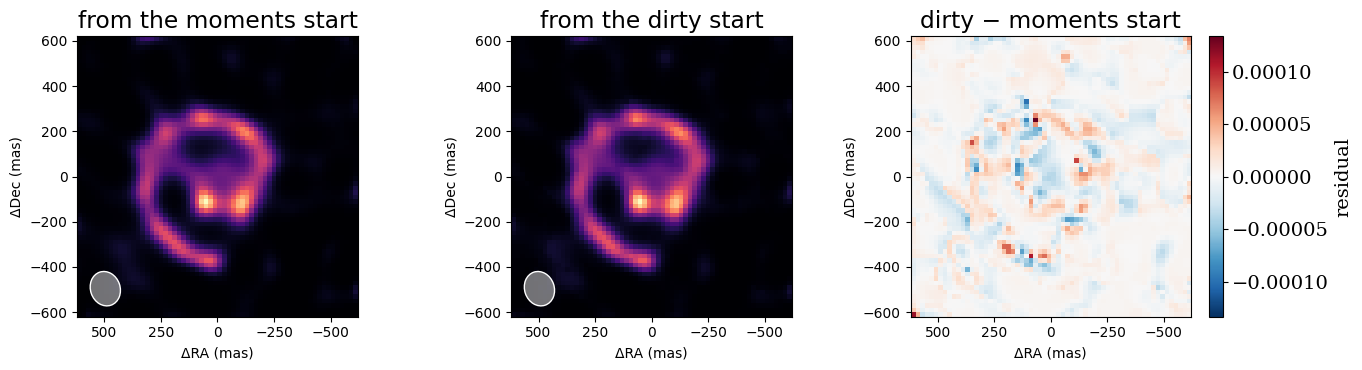

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, name in zip(axes, results):
    plot_model(
        results[name].model.env,
        fov_mas=fov,
        npix=npix,
        ax=ax,
        title=f"from the {name} start",
        beam=resolution,
    )
difference = results["dirty"].model.env.render(npix, fov) - results[
    "moments"
].model.env.render(npix, fov)
plot_residual_map(
    difference, fov_mas=fov, ax=axes[2], title="dirty − moments start"
)
plt.tight_layout()
plt.show()

## Summary

For dense Fourier coverage such as AMIGO's uv grid, the dirty image is a blurred picture of the brightest structure, and starting from it reaches the same reconstruction as starting from a fitted Gaussian in about a quarter of the steps. For sparse coverage the dirty image is dominated by sidelobes, and with only V² and closure phases (classical aperture masking, VLTI, CHARA) there is none at all; `starting_image` then uses the moments start, which needs only amplitudes. Stage 4 covers that case.